# Denoising LIGO data with seqARIMA

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/OddThumb/beacon-py/blob/main/examples/seqarima_denoising.ipynb)

seqARIMA is the denoising stage of BEACON, a data-driven, template-free pipeline for
unmodeled gravitational-wave transients. This notebook fits the noise model on real LIGO
strain, whitens the data around GW150914, and checks that the model captured the noise
without learning the signal. It covers the denoising stage only; the anomaly detection,
clustering, coincidence and veto stages are not exercised here.

It runs in well under a minute and needs no local data: the strain is fetched from GWOSC.

## Setup

Run the next cell on Google Colab. Skip it if `beacon-py` is already installed.

In [1]:
# !pip install -q git+https://github.com/OddThumb/beacon-py.git pycbc

## 1. Load real LIGO data

`Merger` downloads 32 s of strain around GW150914 from GWOSC and caches it locally.
`bc.ts` is the BEACON time-series class; `from_pycbc` converts a PyCBC `TimeSeries` into one.

In [2]:
import warnings
warnings.filterwarnings("ignore")  # quiet the PyCBC/LAL import banner

from pycbc.catalog import Merger
import beacon as bc

merger = Merger("GW150914")
tgps = merger.time

h1 = bc.ts.from_pycbc(merger.strain("H1"))
l1 = bc.ts.from_pycbc(merger.strain("L1"))

print(f"event GPS : {tgps}")
print(f"duration  : {h1.duration:.0f} s at {h1.sampling_freq:.0f} Hz")

lal.MSUN_SI != Msun
event GPS : 1126259462.4
duration  : 32 s at 4096 Hz


## 2. Split the data into off-source and on-source

BEACON never fits its noise model on the data it is searching. The autoregressive model is
estimated on an **off-source** stretch that is free of the event, and the fitted filter is then
applied to the **on-source** stretch. Fitting and filtering the same samples would let the noise
model absorb part of the signal, which biases everything downstream.

GWOSC returns 32 s centred on the event, so the leading stretch serves as off-source here.

In [3]:
off_end = tgps - 2.0  # keep a margin between the fitting data and the event

off_h1 = h1.window(start=h1.start, end=off_end)
off_l1 = l1.window(start=l1.start, end=off_end)

print(f"off-source : {off_h1.duration:.1f} s, ending {tgps - off_end:.0f} s before the event")
print(f"on-source  : {h1.duration:.0f} s")

off-source : 13.4 s, ending 2 s before the event
on-source  : 32 s


## 3. Fit off-source, then filter on-source

seqARIMA suppresses instrumental noise in a sequence of stages.

| stage | argument | what it does |
|---|---|---|
| Difference | `d` | removes non-stationary drift; `"auto"` selects the order |
| Autoregressive | `p`, `ar_ic` | whitens the coloured noise; the order is selected by the
  information criterion `ar_ic` up to the bound `p` |
| Bandpass | `fl`, `fu` | keeps the band where the search is sensitive |

An optional ensemble-of-averages stage (`q`) is available but not used here, and the
published pipeline does not use it either. A moving-average filter rolls off the high end of
the band and undoes part of the whitening: switching it on roughly halves the spectral
flatness of the residual and leaves only 4% of the power between 350 and 480 Hz.

`fit_seqarima` runs those stages on the off-source data and returns the fitted noise model.
`pred_seqarima` then applies that same model to the on-source data.

In [4]:
import beacon.seqARIMA as arm

# Same denoising configuration as the published BEACON campaign.
# The published campaign uses p=1024 on O3 data. On this O1 stretch that bound is
# binding: with p=2048 the criterion settles at a higher order and whitens better.
settings = dict(p=2048, d="auto", ar_ic="HQIC", fl=32, fu=512)

_, noise_model_h1 = arm.fit_seqarima(off_h1, verbose=False, **settings)
_, noise_model_l1 = arm.fit_seqarima(off_l1, verbose=False, **settings)

denoised_h1 = arm.pred_seqarima(h1, params=noise_model_h1, verbose=False)
denoised_l1 = arm.pred_seqarima(l1, params=noise_model_l1, verbose=False)

print(f"H1 AR order : {len(noise_model_h1.ar_coef)}")
print(f"L1 AR order : {len(noise_model_l1.ar_coef)}")

H1 AR order : 1670
L1 AR order : 1932


## 4. See the chirp

`plot_spectro` draws a Q-transform spectrogram with the oscillogram underneath.

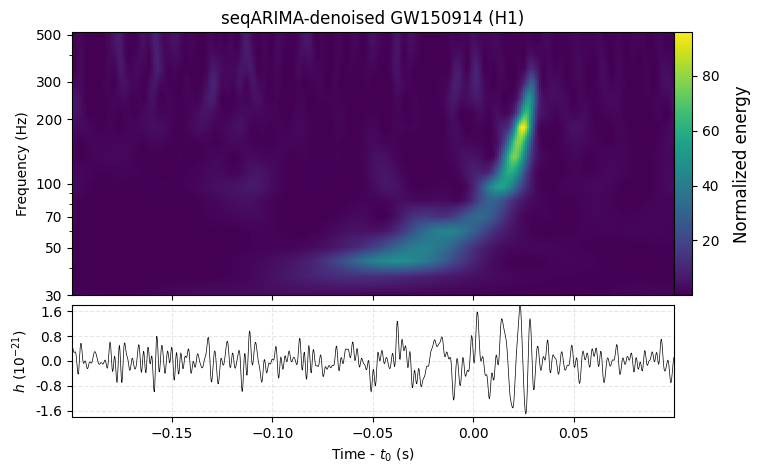

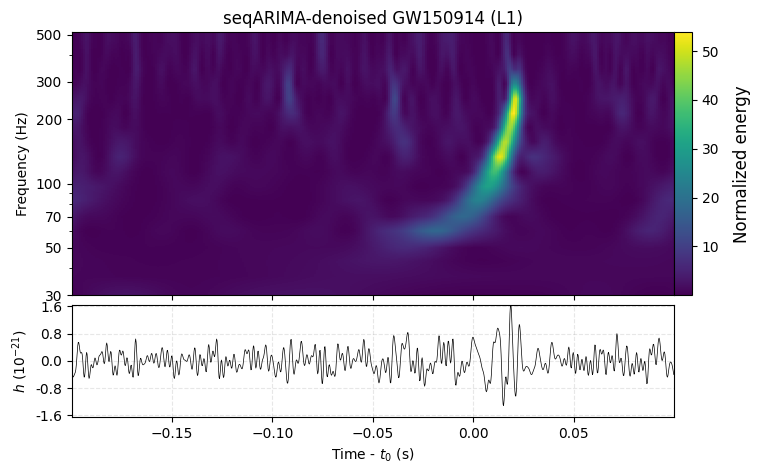

In [5]:
fig = bc.plot.plot_spectro(
    denoised_h1,
    tzero=tgps,
    trange=(tgps - 0.2, tgps + 0.1),
    title="seqARIMA-denoised GW150914 (H1)",
)
fig = bc.plot.plot_spectro(
    denoised_l1,
    tzero=tgps,
    trange=(tgps - 0.2, tgps + 0.1),
    title="seqARIMA-denoised GW150914 (L1)",
)


The track sweeping from roughly 35 Hz to 300 Hz over the last tenth of a second is the
binary black hole merger. Nothing about the waveform was assumed: no template bank was
used, and the noise model was estimated from the data itself.

## 5. Both detectors

A real signal appears in both interferometers within the light travel time between them,
which is 10 ms at most. BEACON uses that coincidence to separate signals from local noise.

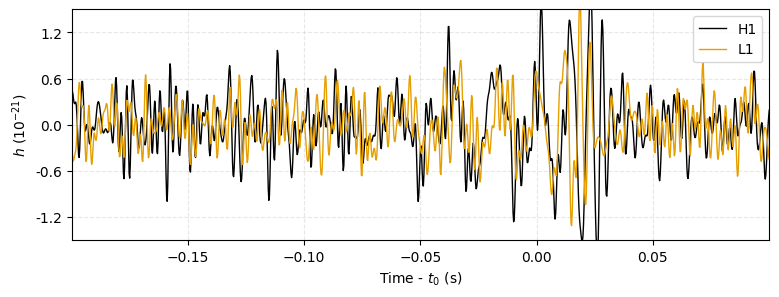

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3))
window = (tgps - 0.2, tgps + 0.1)
bc.plot.plot_oscillo(denoised_h1, tzero=tgps, trange=window, lw=1, ax=ax, label="H1")
bc.plot.plot_oscillo(denoised_l1, tzero=tgps, trange=window, lw=1, ax=ax, label="L1",
                     ylim=(-1.5e-21, 1.5e-21))
ax.legend()
plt.show()

## 6. Is the noise model right?

Two direct checks. Does the model reproduce the measured noise, and is the residual actually
white? Both are read off the power spectrum: the model PSD is available in closed form from
the fitted coefficients through `psd_seqarima`.

measured / model PSD, continuum only : 1.023
                      at 60 Hz line  : 0.170
spectral flatness of the residual    : 0.937
residual PSD spread                  : 0.027 to 2.39 x median


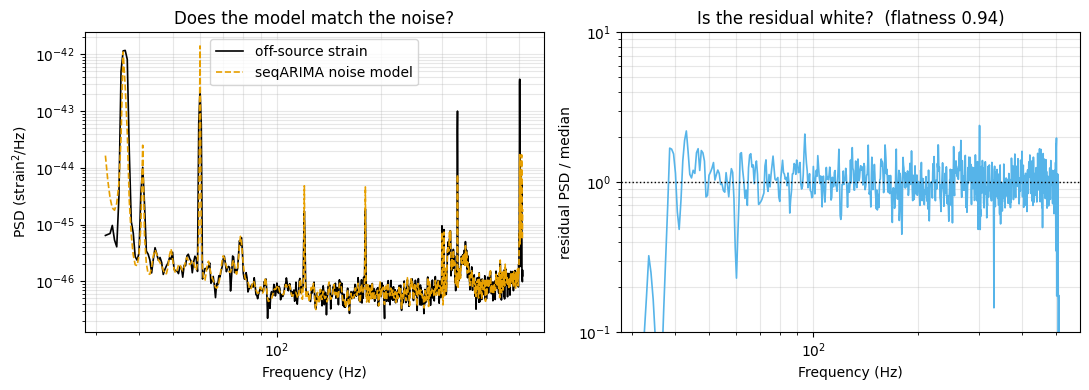

In [7]:
import numpy as np
from scipy.signal import welch

f, psd_strain = welch(off_h1.data, fs=h1.sampling_freq, nperseg=8192)
_, psd_resid = welch(denoised_h1.data, fs=h1.sampling_freq, nperseg=8192)
band = (f >= 32) & (f <= 512)

psd_model = arm.psd_seqarima(f[band], noise_model_h1)
flatness = np.exp(np.mean(np.log(psd_resid[band]))) / np.mean(psd_resid[band])

ratio = psd_strain[band] / psd_model
off_line = np.ones_like(f[band], dtype=bool)
for line in (35, 60, 120, 180, 240, 300, 332, 360, 420, 480, 502):
    off_line &= np.abs(f[band] - line) > 2
norm_resid = psd_resid[band] / np.median(psd_resid[band])

print(f"measured / model PSD, continuum only : {np.median(ratio[off_line]):.3f}")
print(f"                      at 60 Hz line  : {ratio[np.argmin(np.abs(f[band] - 60))]:.3f}")
print(f"spectral flatness of the residual    : {flatness:.3f}")
print(f"residual PSD spread                  : {norm_resid.min():.3f} to {norm_resid.max():.2f} x median")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].loglog(f[band], psd_strain[band], lw=1.2, label="off-source strain")
axes[0].loglog(f[band], psd_model, lw=1.2, ls="--", label="seqARIMA noise model")
axes[0].set_title("Does the model match the noise?")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel(r"PSD (strain$^2$/Hz)")
axes[0].legend()
axes[0].grid(alpha=0.3, which="both")

axes[1].loglog(f[band], psd_resid[band] / np.median(psd_resid[band]), lw=1.2, color="C2")
axes[1].axhline(1.0, ls=":", color="k", lw=1)
axes[1].set_ylim(1e-1, 1e1)
axes[1].set_title(f"Is the residual white?  (flatness {flatness:.2f})")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("residual PSD / median")
axes[1].grid(alpha=0.3, which="both")

fig.tight_layout()
plt.show()

The two panels say different things, and the second one is the more interesting.

The **continuum** is reproduced almost exactly: away from the narrow lines the measured and
modelled spectra agree to within a few percent. That is the part of the noise the search
cares about, and it is why the residual is flat to within a factor of a few across most of
the band.

The **narrow lines are not**. An autoregressive model of order $p$ resolves frequency only to
about $f_s/p$, here roughly 2.5 Hz, so a line under 1 Hz wide is smeared: the 60 Hz mains
line comes out several times too strong, while the 332 Hz and 502 Hz suspension violin modes
come out more than an order of magnitude too weak. Each mismatch leaves a mark in the
residual, which is why its spectrum still ranges from a fortieth of the median to twice it.
Those marks are a known limitation of the denoising stage, and the pipeline deals with them
downstream rather than by pushing the autoregressive order higher.

The signal, meanwhile, survives. Over 100-250 Hz the event-window peak sits at 10.8 times the
background level in the raw strain and at 12.1 in the residual. Had the fit absorbed the
transient, that ratio would have dropped instead of rising, which is the reason the model is
estimated off-source in step 2.

## Where to go next

- The full pipeline adds anomaly detection, DBSCAN clustering, a significance model and a
  cross-detector veto on top of this denoising step. See the README for the overview.
- `bc.Pipe` runs those stages on batched or streaming data.
- Issues and questions: https://github.com/OddThumb/beacon-py/issues